# k-means from scratch, and how many clusters there are

Aurora, an online retailer, wants to group its 2,000 customers into
segments for a marketing campaign — but nobody has ever labelled a customer
as belonging to a segment. There is no $y$ anywhere in this notebook. This
is what makes the problem **unsupervised**: the only thing to work with is
the shape of the data itself, and the only question a clustering algorithm
answers is "which points look like they belong together?"

This notebook builds **k-means** from scratch, checks it against
scikit-learn, and then asks the question every clustering method defers:
*how many groups are there?* Handout section 2 carries the full derivation
of why Lloyd's algorithm converges.

## 1. Setup

In [1]:
# pip install numpy==1.26.4 pandas==2.1.1 matplotlib==3.8.0 scikit-learn==1.3.1

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score

from retail_data import make_customer_segments, TRUE_N_SEGMENTS, TRUE_SEGMENT_NAMES

FIGURES = Path.cwd().parent / "Figures"
FIGURES.mkdir(exist_ok=True)

BLUE, TEAL, RUST, GOLD, PLUM = "#1F4E79", "#2E8B8B", "#B4483E", "#C9A227", "#7B4B94"
PALETTE = [BLUE, TEAL, RUST, GOLD, PLUM]

RNG_SEED = 42
np.random.seed(RNG_SEED)

customers = make_customer_segments()
X = customers[["annual_spend_eur", "visits_per_month"]].values
scaler = StandardScaler()
Xs = scaler.fit_transform(X)

print(f"{len(customers)} customers, 2 features, {TRUE_N_SEGMENTS} true segments "
      f"(never shown to any model below)")
customers.head()

2000 customers, 2 features, 4 true segments (never shown to any model below)


,annual_spend_eur,visits_per_month,true_segment
0,842.053353,5.911342,loyal high spenders
1,827.452084,5.062865,loyal high spenders
2,60.675247,1.189117,window shoppers
3,973.706252,0.100000,occasional big spenders
4,1082.809438,6.440865,loyal high spenders


## 2. Look at it first, unlabelled

This is what Aurora's marketing team actually has: two numbers per
customer, no group name attached to either. Whatever structure is visible
below has to come from the geometry alone.

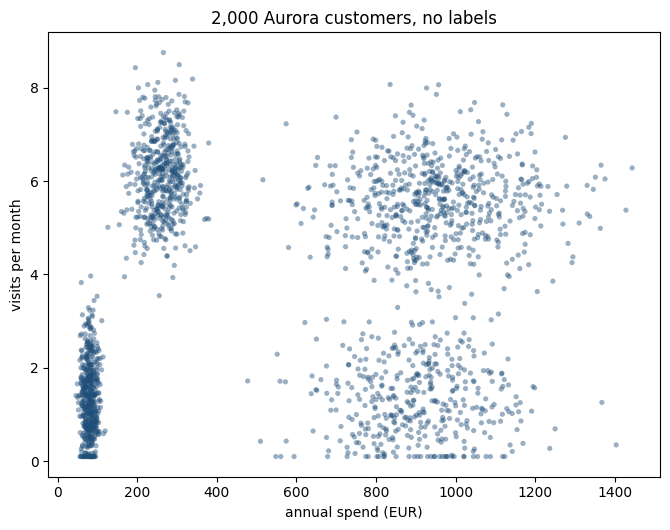

In [2]:
fig, ax = plt.subplots(figsize=(6.8, 5.4))
ax.scatter(X[:, 0], X[:, 1], s=14, color=BLUE, alpha=.45, edgecolor="none")
ax.set_xlabel("annual spend (EUR)")
ax.set_ylabel("visits per month")
ax.set_title("2,000 Aurora customers, no labels")
fig.tight_layout()
fig.savefig(FIGURES / "customers_unlabelled.png", dpi=150)
plt.show()

Four clouds are visible to the eye even before any algorithm runs — that
is not an accident of this dataset, it is the property k-means is built to
exploit: it assumes the data really does live in a small number of
roughly round, roughly equal-spread blobs, and it will impose that
structure on the data whether or not the assumption holds. Notebook 02
is entirely about what happens when it does not.

## 3. The objective: within-cluster sum of squares

k-means asks for the assignment of every point to one of $k$ groups, and
the $k$ group centres, that together minimise the total squared distance
from each point to its own centre:

$$J(\{\mu_j\}, \{r_{ij}\}) = \sum_{i=1}^{m} \sum_{j=1}^{k} r_{ij} \, \lVert x_i - \mu_j \rVert^2$$

where $r_{ij} = 1$ if point $i$ is assigned to cluster $j$ and $0$
otherwise. This quantity is called the **within-cluster sum of squares**
(WCSS), or *inertia* in scikit-learn. It cannot be minimised in one shot —
choosing the best assignment needs the centres, and choosing the best
centres needs the assignment — so **Lloyd's algorithm** alternates the two
steps, each of which has a closed-form solution given the other:

1. **Assign**: give each point to its nearest centre.
2. **Update**: move each centre to the mean of the points now assigned to
   it.

Each step can only decrease $J$ or leave it unchanged (handout section 2.1
proves both halves), so alternating them converges — to *a* minimum, not
necessarily *the* minimum, which is exactly the problem the next section
demonstrates.

In [3]:
def assign_step(X, centers):
    dists = np.sum((X[:, None, :] - centers[None, :, :]) ** 2, axis=2)
    return np.argmin(dists, axis=1)


def update_step(X, labels, k):
    return np.array([
        X[labels == j].mean(axis=0) if np.any(labels == j) else X[np.random.choice(len(X))]
        for j in range(k)
    ])


def wcss(X, labels, centers):
    return np.sum((X - centers[labels]) ** 2)


def lloyd(X, centers0, max_iter=100, tol=1e-8):
    centers = centers0.copy()
    for it in range(max_iter):
        labels = assign_step(X, centers)
        new_centers = update_step(X, labels, len(centers))
        shift = np.sum((new_centers - centers) ** 2)
        centers = new_centers
        if shift < tol:
            break
    labels = assign_step(X, centers)
    return centers, labels, wcss(X, labels, centers), it + 1

### 3.1 A bad start is a real risk, not a technicality

Lloyd's algorithm is only guaranteed to find *some* local minimum of $J$,
and which one depends entirely on where the centres start. To see this
plainly, run it from 30 different naive starting points — $k$ points
chosen uniformly at random from the data — and record the best and worst
final WCSS.

In [4]:
results = []
for seed in range(30):
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(Xs), TRUE_N_SEGMENTS, replace=False)
    centers, labels, final_wcss, n_iter = lloyd(Xs, Xs[idx])
    results.append({"seed": seed, "wcss": final_wcss, "iterations": n_iter})

naive_results = pd.DataFrame(results)
best_row = naive_results.loc[naive_results["wcss"].idxmin()]
worst_row = naive_results.loc[naive_results["wcss"].idxmax()]
print(f"best of 30 naive starts : WCSS = {best_row['wcss']:.1f}  (seed {int(best_row['seed'])})")
print(f"worst of 30 naive starts: WCSS = {worst_row['wcss']:.1f}  (seed {int(worst_row['seed'])})")
print(f"ratio worst/best        : {worst_row['wcss'] / best_row['wcss']:.2f}x")

best of 30 naive starts : WCSS = 374.1  (seed 0)
worst of 30 naive starts: WCSS = 1390.4  (seed 28)
ratio worst/best        : 3.72x


A factor of several between the best and worst run of the *same*
algorithm on the *same* data, with only the starting point different,
is the practical argument for a smarter initialisation than "pick $k$
points at random" — and for running several restarts and keeping the
best regardless.

**k-means++** spends a little more work up front to buy a much better
typical start: the first centre is a uniformly random point, and every
centre after that is chosen with probability proportional to its squared
distance from the nearest centre already picked. Points far from every
existing centre — the ones most likely to seed a *new* cluster rather than
duplicate one already found — are the ones most likely to be chosen.

In [5]:
def kmeans_pp_init(X, k, rng):
    n = X.shape[0]
    centers = [X[rng.integers(n)]]
    for _ in range(1, k):
        d2 = np.min([np.sum((X - c) ** 2, axis=1) for c in centers], axis=0)
        probs = d2 / d2.sum()
        centers.append(X[rng.choice(n, p=probs)])
    return np.array(centers)


pp_results = []
for seed in range(30):
    rng = np.random.default_rng(seed)
    centers0 = kmeans_pp_init(Xs, TRUE_N_SEGMENTS, rng)
    centers, labels, final_wcss, n_iter = lloyd(Xs, centers0)
    pp_results.append(final_wcss)

pp_results = np.array(pp_results)
print(f"k-means++ starts: best = {pp_results.min():.1f}, worst = {pp_results.max():.1f}, "
      f"mean = {pp_results.mean():.1f}")
print(f"naive starts    : best = {naive_results['wcss'].min():.1f}, "
      f"worst = {naive_results['wcss'].max():.1f}, mean = {naive_results['wcss'].mean():.1f}")

k-means++ starts: best = 374.1, worst = 1088.3, mean = 397.9
naive starts    : best = 374.1, worst = 1390.4, mean = 408.0


### 3.2 Checked against scikit-learn

`sklearn.cluster.KMeans` uses k-means++ by default and, unless told
otherwise, restarts 10 times and keeps the best run — which is exactly the
scratch procedure above, compiled. Confirm the final WCSS matches to a
sensible tolerance.

In [6]:
rng = np.random.default_rng(0)
centers0 = kmeans_pp_init(Xs, TRUE_N_SEGMENTS, rng)
scratch_centers, scratch_labels, scratch_wcss, _ = lloyd(Xs, centers0)

sk_kmeans = KMeans(n_clusters=TRUE_N_SEGMENTS, n_init=10, random_state=0).fit(Xs)

print(f"from scratch (k-means++, 1 run) : WCSS = {scratch_wcss:.4f}")
print(f"scikit-learn (k-means++, 10 runs): WCSS = {sk_kmeans.inertia_:.4f}")
print(f"difference                       : {abs(scratch_wcss - sk_kmeans.inertia_):.6f}")

from scratch (k-means++, 1 run) : WCSS = 374.0919
scikit-learn (k-means++, 10 runs): WCSS = 374.0919
difference                       : 0.000000


## 4. How many clusters? The elbow and the silhouette

k-means takes $k$ as an input, not an output — nothing about the algorithm
says how many groups there ought to be. Two diagnostics fill that gap, and
they measure different things.

**WCSS against $k$** always decreases as $k$ grows — with $k = m$ every
point is its own cluster and WCSS is exactly $0$ — so the useful signal is
not the value but where the curve stops falling steeply: the **elbow**.

**Silhouette score** for a point $i$ compares its mean distance to its own
cluster, $a_i$, against its mean distance to the *nearest other* cluster,
$b_i$:

$$s_i = \frac{b_i - a_i}{\max(a_i, b_i)}$$

$s_i$ is close to $1$ when a point sits comfortably inside its own cluster
and far from every other, close to $0$ on a boundary, and negative when a
point is, on average, closer to a different cluster than its own — an
assignment silhouette actively penalises. Averaged over all points, it is
a genuine optimum to look for, not just a bend to eyeball.

In [7]:
ks = range(1, 9)
wcss_curve, silhouette_curve = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(Xs)
    wcss_curve.append(km.inertia_)
    silhouette_curve.append(silhouette_score(Xs, km.labels_) if k > 1 else np.nan)

curve_table = pd.DataFrame({"k": list(ks), "wcss": wcss_curve, "silhouette": silhouette_curve})
curve_table

,k,wcss,silhouette
0,1,4000.000000,NaN
1,2,2128.532902,0.471585
2,3,1125.762916,0.563593
3,4,374.091918,0.689865
4,5,320.604546,0.592714
5,6,286.485903,0.525491
6,7,244.459594,0.528365
7,8,210.367912,0.473938


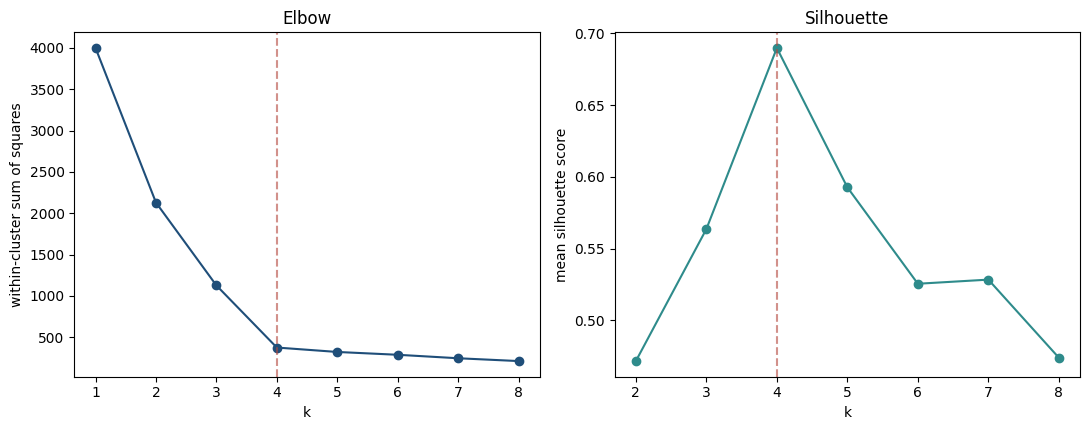

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.4))
ax1.plot(curve_table["k"], curve_table["wcss"], "o-", color=BLUE)
ax1.set_xlabel("k"); ax1.set_ylabel("within-cluster sum of squares")
ax1.set_title("Elbow")
ax1.axvline(TRUE_N_SEGMENTS, color=RUST, linestyle="--", alpha=.6)

ax2.plot(curve_table["k"][1:], curve_table["silhouette"][1:], "o-", color=TEAL)
ax2.set_xlabel("k"); ax2.set_ylabel("mean silhouette score")
ax2.set_title("Silhouette")
ax2.axvline(TRUE_N_SEGMENTS, color=RUST, linestyle="--", alpha=.6)

fig.tight_layout()
fig.savefig(FIGURES / "elbow_silhouette.png", dpi=150)
plt.show()

Both diagnostics agree here: WCSS falls sharply through $k = 4$ and then
flattens, and the silhouette score peaks at $k = 4$ (0.690) before
declining. That agreement is worth noticing precisely because it is not
guaranteed — the two measure different things, and section 5 of the
handout works through a case where they disagree.

## 5. The recovered segments, checked against the ground truth

In [9]:
final_km = KMeans(n_clusters=TRUE_N_SEGMENTS, n_init=10, random_state=0).fit(Xs)
ari = adjusted_rand_score(customers["true_segment"], final_km.labels_)

print(f"adjusted Rand index against the (never-shown) true segment: {ari:.4f}")
print(f"silhouette score at k=4: {silhouette_score(Xs, final_km.labels_):.4f}")

adjusted Rand index against the (never-shown) true segment: 0.9850
silhouette score at k=4: 0.6899


The **adjusted Rand index** (ARI) measures agreement between two labellings
of the same points, corrected so that a random assignment scores $0$ and a
perfect match scores $1$; it is available *only* here, in a lesson built
on synthetic data where the true segment is known — Aurora's marketing
team, working the real version of this problem, has no such number to
check against, and never will. That asymmetry is worth sitting with: every
number in the rest of this notebook is checkable only because the ground
truth was published in `retail_data.py` before any model saw the data.

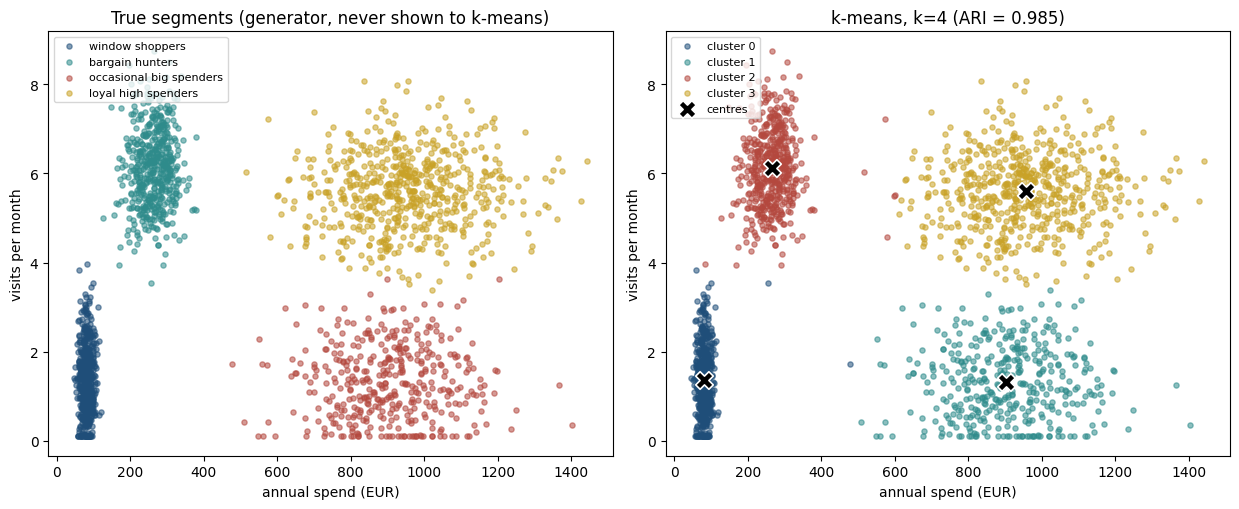

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 5.2))

for j, name in enumerate(TRUE_SEGMENT_NAMES):
    mask = customers["true_segment"] == name
    ax1.scatter(X[mask, 0], X[mask, 1], s=14, color=PALETTE[j], alpha=.55, label=name)
ax1.set_title("True segments (generator, never shown to k-means)")
ax1.set_xlabel("annual spend (EUR)"); ax1.set_ylabel("visits per month")
ax1.legend(fontsize=8, loc="upper left")

for j in range(TRUE_N_SEGMENTS):
    mask = final_km.labels_ == j
    ax2.scatter(X[mask, 0], X[mask, 1], s=14, color=PALETTE[j], alpha=.55, label=f"cluster {j}")
centers_original = scaler.inverse_transform(final_km.cluster_centers_)
ax2.scatter(centers_original[:, 0], centers_original[:, 1], marker="X", s=160,
            color="black", edgecolor="white", linewidth=1.2, zorder=5, label="centres")
ax2.set_title(f"k-means, k=4 (ARI = {ari:.3f})")
ax2.set_xlabel("annual spend (EUR)"); ax2.set_ylabel("visits per month")
ax2.legend(fontsize=8, loc="upper left")

fig.tight_layout()
fig.savefig(FIGURES / "kmeans_vs_truth.png", dpi=150)
plt.show()

## 6. The predictable mistake

Most students, having watched k-means recover this data almost perfectly,
will conclude it is a generally reliable way to find groups. **The
reasoning is sound as far as it goes** — on data that really is shaped as a
handful of roughly round, roughly equal-spread blobs, k-means is fast and
close to optimal. The instinct fails only on the assumption behind it: real
customer, sensor or network data has no obligation to be round.

Notebook 02 builds a dataset by design where that assumption breaks —
one dense group nested inside a diffuse ring around it — and asks k-means
to separate them.

## Summary

- k-means minimises within-cluster sum of squares by alternating an
  assignment step and an update step (Lloyd's algorithm); each step can
  only lower the objective, so it always converges — to *a* local minimum.
- Initialisation matters: 30 naive random starts on this dataset ranged
  from the global optimum to several times worse; k-means++ narrows that
  gap by preferring centres far from ones already chosen.
- The elbow (WCSS against $k$) and the silhouette score are two different
  diagnostics for choosing $k$; here they agree, both pointing to $k = 4$,
  which matches the number of segments the data was built with.
- The from-scratch implementation matches scikit-learn's `KMeans` to
  within numerical tolerance.
- k-means assumes clusters are convex and comparably sized. The next
  notebook is built specifically to break that assumption.